In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df_tratado = pd.read_csv('/content/drive/My Drive/absenteeism_tratado.csv' )

In [5]:
df_tratado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 706 entries, 0 to 705
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   ID                               706 non-null    int64  
 1   Reason_for_absence               706 non-null    object 
 2   Month_of_absence                 706 non-null    int64  
 3   Day_of_the_week                  706 non-null    int64  
 4   Seasons                          706 non-null    int64  
 5   Transportation_expense           706 non-null    float64
 6   Distance_from_Residence_to_Work  706 non-null    float64
 7   Service_time                     706 non-null    float64
 8   Age                              706 non-null    float64
 9   Work_load_Average_day            706 non-null    float64
 10  Hit_target                       706 non-null    float64
 11  Disciplinary_failure             706 non-null    int64  
 12  Education             

In [6]:
df_tratado.head()

,ID,Reason_for_absence,Month_of_absence,Day_of_the_week,Seasons,Transportation_expense,Distance_from_Residence_to_Work,Service_time,Age,Work_load_Average_day,...,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_time_in_hours,hours_winsorized
0,11,26,7,3,1,289.0,36.0,13.0,33.0,239554.0,...,1,2.0,1,0,1.0,90.0,172.0,30.0,4.0,4.0
1,36,Punição Disciplinar,7,3,1,118.0,13.0,18.0,50.0,239554.0,...,1,1.0,1,0,0.0,98.0,178.0,31.0,0.0,0.0
2,3,23,7,4,1,179.0,51.0,18.0,38.0,239554.0,...,1,0.0,1,0,0.0,89.0,170.0,31.0,2.0,2.0
3,7,7,7,5,1,279.0,5.0,14.0,39.0,239554.0,...,1,2.0,1,1,0.0,68.0,168.0,24.0,4.0,4.0
4,11,23,7,5,1,289.0,36.0,13.0,33.0,239554.0,...,1,2.0,1,0,1.0,90.0,172.0,30.0,2.0,2.0


In [7]:
df_tratado.describe()

,ID,Month_of_absence,Day_of_the_week,Seasons,Transportation_expense,Distance_from_Residence_to_Work,Service_time,Age,Work_load_Average_day,Hit_target,...,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_time_in_hours,hours_winsorized
count,706.000000,706.000000,706.000000,706.000000,706.000000,706.000000,706.000000,706.000000,706.000000,706.000000,...,706.000000,706.000000,706.000000,706.000000,706.000000,706.000000,706.000000,706.000000,706.000000,706.000000
mean,18.192635,6.430595,3.890935,2.549575,222.977337,29.297450,12.495751,36.478754,272089.984419,94.548159,...,1.291785,1.060907,0.565156,0.076487,0.769122,79.005666,172.202550,26.635977,5.613314,5.613314
std,10.927472,3.383544,1.425503,1.121527,67.293426,14.706661,4.370190,6.563404,39458.780251,3.803854,...,0.671499,1.104717,0.496088,0.265965,1.333351,12.862501,6.159814,4.254901,5.827963,5.827963
min,1.000000,1.000000,2.000000,1.000000,118.000000,5.000000,1.000000,27.000000,205917.000000,81.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,56.000000,163.000000,19.000000,0.000000,0.000000
25%,10.000000,3.000000,3.000000,2.000000,179.000000,16.000000,9.000000,31.000000,244387.000000,92.250000,...,1.000000,0.000000,0.000000,0.000000,0.000000,69.000000,169.000000,24.000000,2.000000,2.000000
50%,18.000000,6.000000,4.000000,3.000000,225.000000,26.000000,13.000000,37.000000,264604.000000,95.000000,...,1.000000,1.000000,1.000000,0.000000,0.000000,80.000000,171.000000,25.000000,3.000000,3.000000
75%,28.000000,9.750000,5.000000,4.000000,260.000000,49.000000,16.000000,40.000000,294217.000000,97.000000,...,1.000000,2.000000,1.000000,0.000000,1.000000,89.000000,172.000000,31.000000,8.000000,8.000000
max,36.000000,12.000000,6.000000,4.000000,388.000000,52.000000,29.000000,58.000000,378884.000000,100.000000,...,4.000000,4.000000,1.000000,1.000000,8.000000,108.000000,196.000000,38.000000,24.000000,24.000000


## Verificação de duplicatas
Foram encontradas 34 linhas duplicadas o que representa 4,59% dos nossos dados, esse tipo de informação podereia causar um inflacionamento no resultado final da análise. Será tratada no ETL.


In [8]:
df_tratado[df_tratado.duplicated()]

,ID,Reason_for_absence,Month_of_absence,Day_of_the_week,Seasons,Transportation_expense,Distance_from_Residence_to_Work,Service_time,Age,Work_load_Average_day,...,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_time_in_hours,hours_winsorized
101,34,19,12,3,4,118.0,10.0,10.0,37.0,261306.0,...,1,0.0,0,0,0.0,83.0,172.0,28.0,24.0,24.0


## Verificação de frequência e boxplot de faltas por mês

/tmp/ipykernel_2304/860786356.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=frequencia_mes.index.astype(int), y=frequencia_mes.values, palette='gray')


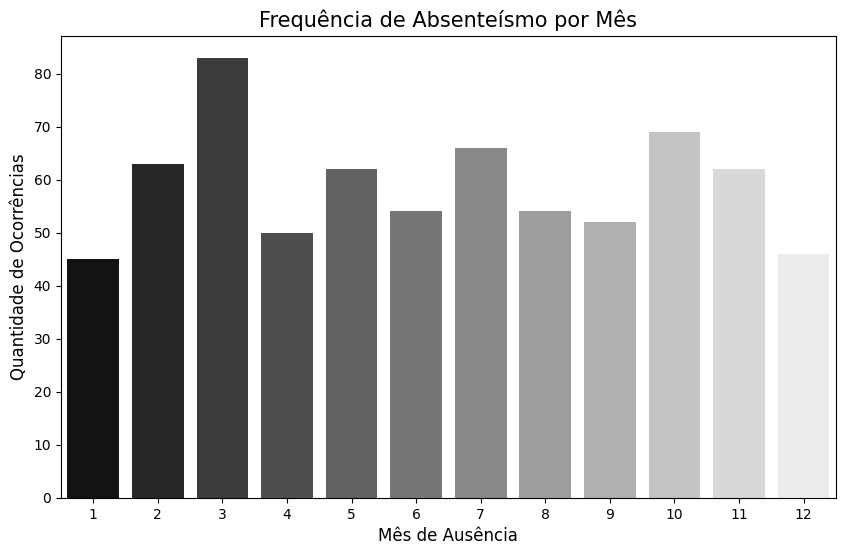

In [9]:
# Calcula a frequência e ordena pelos meses
frequencia_mes = df_tratado['Month_of_absence'].value_counts().sort_index()

# Configura o visual do gráfico
plt.figure(figsize=(10, 6))
sns.barplot(x=frequencia_mes.index.astype(int), y=frequencia_mes.values, palette='gray')

# Adiciona títulos e rótulos
plt.title('Frequência de Absenteísmo por Mês', fontsize=15)
plt.xlabel('Mês de Ausência', fontsize=12)
plt.ylabel('Quantidade de Ocorrências', fontsize=12)

# Exibe o gráfico
plt.show()

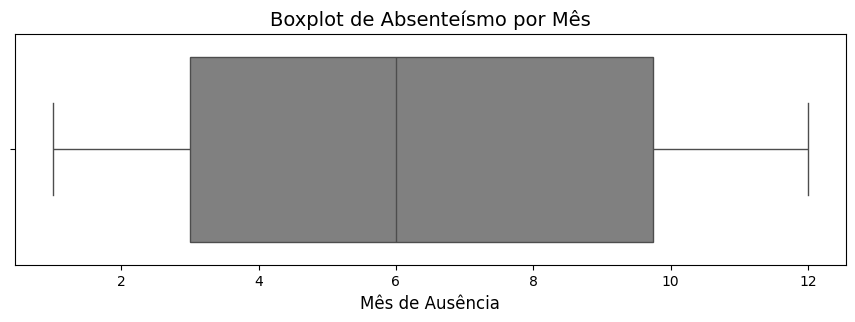

In [10]:
plt.figure(figsize=(10.72, 3))
sns.boxplot(x=df_tratado['Month_of_absence'], orient='h', color='gray')
plt.title('Boxplot de Absenteísmo por Mês', fontsize=14)
plt.xlabel('Mês de Ausência', fontsize=12)
plt.show()

## Verificação de frequência e boxplot de faltas em horas

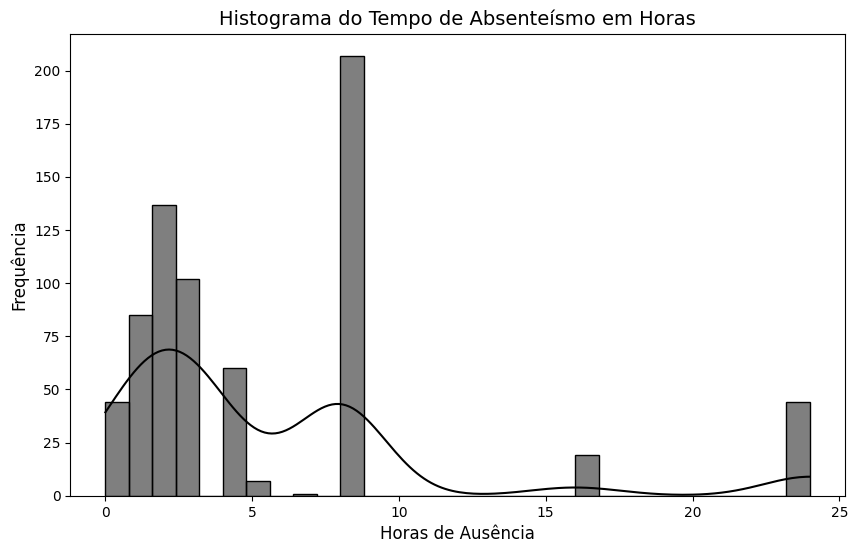

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(df_tratado['Absenteeism_time_in_hours'], kde=True, color='black', bins=30)
plt.title('Histograma do Tempo de Absenteísmo em Horas', fontsize=14)
plt.xlabel('Horas de Ausência', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.show()

In [12]:
df_tratado['Absenteeism_time_in_hours'].describe()

IQR = df_tratado['Absenteeism_time_in_hours'].quantile(0.75) - df_tratado['Absenteeism_time_in_hours'].quantile(0.25)
Limite_Superior = df_tratado['Absenteeism_time_in_hours'].quantile(0.75) + 1.5 * IQR

print("\nIQR =", IQR)
print("Limite Superior =", Limite_Superior)


IQR = 6.0
Limite Superior = 17.0


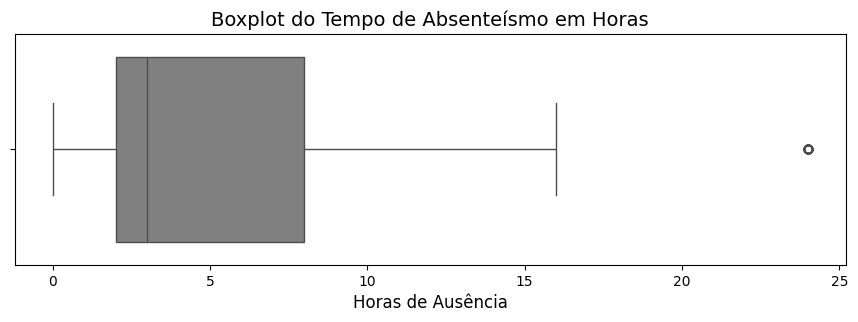

In [13]:
# 3. Gerar um Boxplot horizontal para destacar visualmente os pontos fora da curva.
plt.figure(figsize=(10.72, 3))
sns.boxplot(x=df_tratado['Absenteeism_time_in_hours'], orient='h', color='gray')
plt.title('Boxplot do Tempo de Absenteísmo em Horas', fontsize=14)
plt.xlabel('Horas de Ausência', fontsize=12)
plt.show()

In [14]:
import numpy as np

# 1. Calcular as estatísticas descritivas e o Limite Superior usando a regra do IQR

# Já calculamos o Q1, Q3, IQR, lower_bound e upper_bound na célula anterior (yzILYfmMZhHs)
# Reutilizando os valores para garantir consistência:
# Q1_absenteeism = df_raw['Absenteeism_time_in_hours'].quantile(0.25)
# Q3_absenteeism = df_raw['Absenteeism_time_in_hours'].quantile(0.75)
# IQR_absenteeism = Q3_absenteeism - Q1_absenteeism
# upper_bound_absenteeism = Q3_absenteeism + 1.5 * IQR_absenteeism

Q1_absenteeism = df_tratado['Absenteeism_time_in_hours'].quantile(0.25)
Q3_absenteeism = df_tratado['Absenteeism_time_in_hours'].quantile(0.75)
IQR_absenteeism = Q3_absenteeism - Q1_absenteeism

lower_bound_absenteeism = Q1_absenteeism - 1.5 * IQR_absenteeism
upper_bound_absenteeism = Q3_absenteeism + 1.5 * IQR_absenteeism

print("Estatísticas Descritivas para 'Absenteeism_time_in_hours':")
display(df_tratado['Absenteeism_time_in_hours'].describe())
print(f"Limite Superior para Outliers (Q3 + 1.5 * IQR): {upper_bound_absenteeism}")

# 2. Identificar quantos registros estão acima desse limite e listar os 5 casos mais extremos
outliers_severe = df_tratado[df_tratado['Absenteeism_time_in_hours'] > upper_bound_absenteeism].sort_values(by='Absenteeism_time_in_hours', ascending=False)

print(f"\nNúmero de registros acima do limite superior de outlier: {len(outliers_severe)}")
print("\n5 Casos mais extremos (outliers severos):")
display(outliers_severe[['ID', 'Absenteeism_time_in_hours']].head(5))


Estatísticas Descritivas para 'Absenteeism_time_in_hours':


,Absenteeism_time_in_hours
count,706.000000
mean,5.613314
std,5.827963
min,0.000000
25%,2.000000
50%,3.000000
75%,8.000000
max,24.000000


Limite Superior para Outliers (Q3 + 1.5 * IQR): 17.0

Número de registros acima do limite superior de outlier: 44

5 Casos mais extremos (outliers severos):


,ID,Absenteeism_time_in_hours
8,14,24.0
21,10,24.0
48,15,24.0
83,14,24.0
85,15,24.0


## Verificação da frequência e boxplot da razão da falta

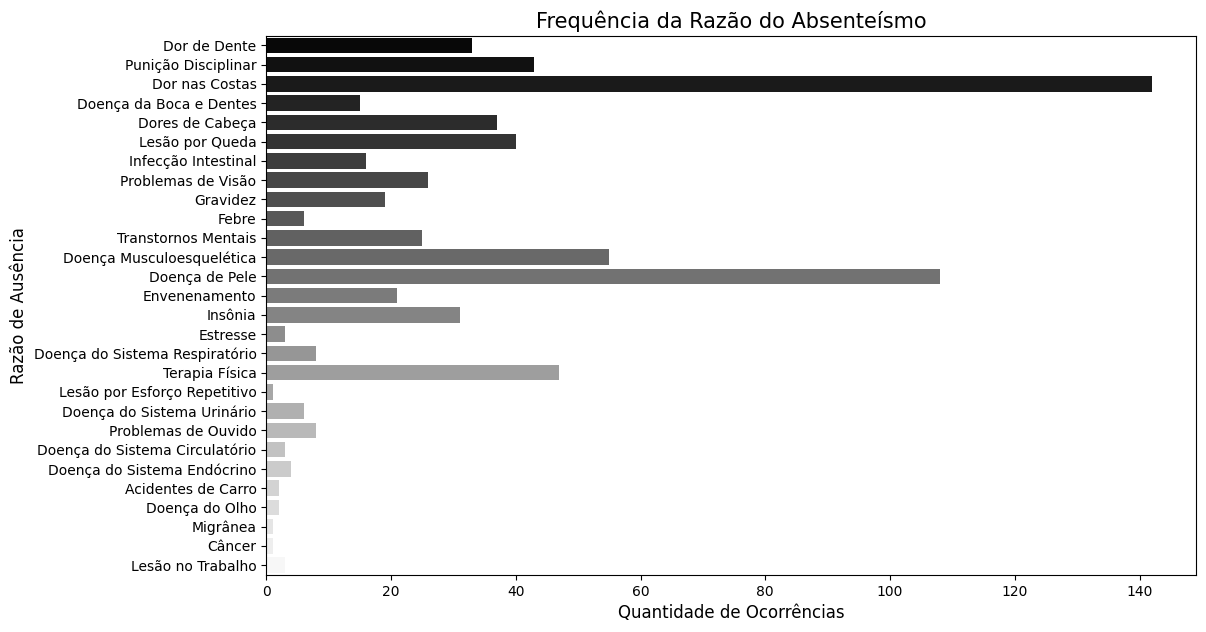

In [48]:
# Dicionário de mapeamento para as razões de ausência
reason_mapping = {
    'Punição Disciplinar': 'Punição Disciplinar',
    1: 'Infecção Intestinal',
    2: 'Câncer',
    3: 'Migrânea',
    4: 'Doença do Olho',
    5: 'Doença do Sistema Circulatório',
    6: 'Doença do Sistema Respiratório',
    7: 'Doença da Boca e Dentes',
    8: 'Doença do Sistema Urinário',
    9: 'Doença do Sistema Endócrino',
    10: 'Transtornos Mentais',
    11: 'Problemas de Visão',
    12: 'Problemas de Ouvido',
    13: 'Doença Musculoesquelética',
    14: 'Gravidez',
    15: 'Acidentes de Carro',
    16: 'Lesão no Trabalho',
    17: 'Lesão por Esforço Repetitivo',
    18: 'Envenenamento',
    19: 'Lesão por Queda',
    20: 'Queimadura',
    21: 'Febre',
    22: 'Dores de Cabeça',
    23: 'Dor nas Costas',
    24: 'Estresse',
    25: 'Insônia',
    26: 'Dor de Dente',
    27: 'Terapia Física',
    28: 'Doença de Pele'
}

# Função para mapear os códigos para nomes descritivos, tratando strings que representam números
def map_reason_name(reason):
    if isinstance(reason, str) and reason.isdigit(): # Check if it's a string that looks like a number
        return reason_mapping.get(int(reason), reason) # Convert to int for lookup
    elif reason in reason_mapping:
        return reason_mapping[reason]
    else:
        return reason # Return original value if no mapping is found

# Mapear os códigos para nomes descritivos em uma nova coluna temporária
df_tratado['Reason_Name_for_Frequency'] = df_tratado['Reason_for_absence'].apply(map_reason_name)

# Calcula a frequência das razões de ausência usando os nomes mapeados, sem ordenar por frequência
frequencia_razao = df_tratado['Reason_Name_for_Frequency'].value_counts(sort=False)

# Configura o visual do gráfico
plt.figure(figsize=(12, 7))
sns.barplot(y=frequencia_razao.index, x=frequencia_razao.values, palette='gray', hue=frequencia_razao.index, legend=False)

# Adiciona títulos e rótulos
plt.title('Frequência da Razão do Absenteísmo', fontsize=15)
plt.ylabel('Razão de Ausência', fontsize=12)
plt.xlabel('Quantidade de Ocorrências', fontsize=12)
# Não é necessário girar os rótulos do eixo X (agora Y) em um gráfico horizontal

# Exibe o gráfico
plt.show()

# Opcional: remover a coluna temporária 'Reason_Name_for_Frequency' se não for mais necessária
df_tratado = df_tratado.drop(columns=['Reason_Name_for_Frequency'])

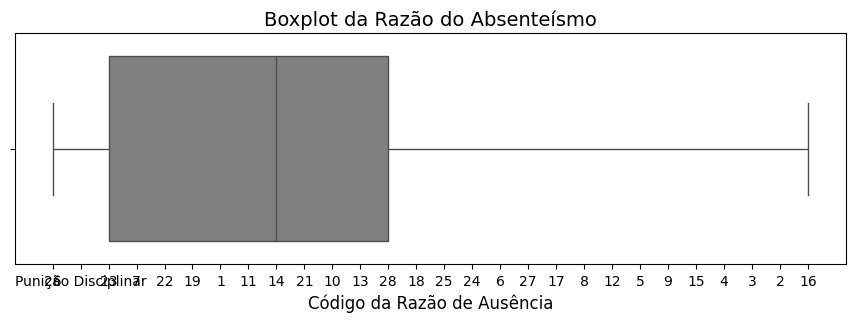

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10.72, 3))
sns.boxplot(x=df_tratado['Reason_for_absence'], orient='h', color='gray')
plt.title('Boxplot da Razão do Absenteísmo', fontsize=14)
plt.xlabel('Código da Razão de Ausência', fontsize=12)
plt.show()

# **Estrutura do Notebook Final (EDA_2)**
**Diferente da primeira EDA, que focou em encontrar erros, esta deve focar em padrões de comportamento. Recomendo as seguintes análises no seu notebook EDA_2:**

### Análise Temporal e Sazonalidade

Vamos explorar as tendências de absenteísmo ao longo do tempo, focando na média de horas de ausência por mês, principais motivos e por estação do ano.

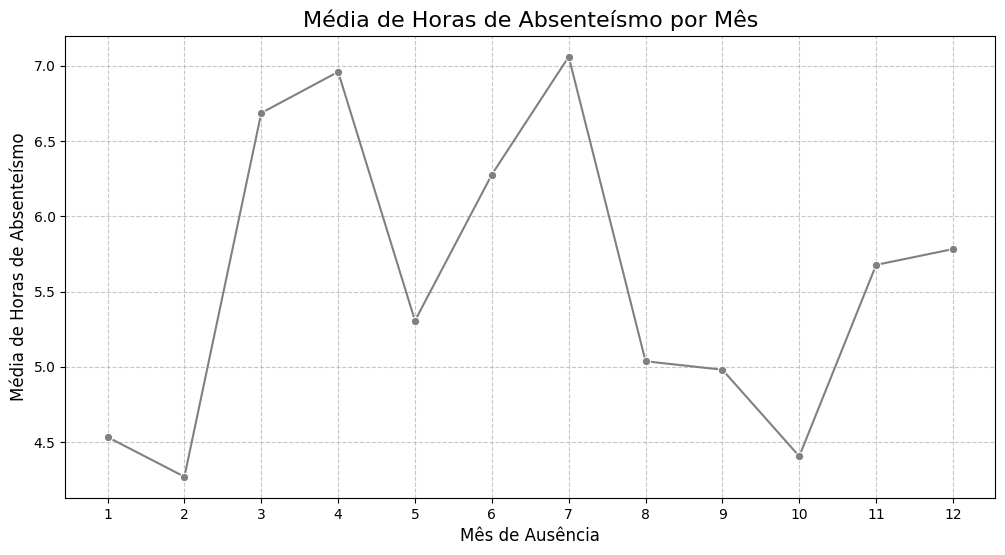

In [46]:
# Gráfico de Linhas: Média de horas de absenteísmo por mês
avg_absenteeism_month = df_tratado.groupby('Month_of_absence')['Absenteeism_time_in_hours'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='Month_of_absence', y='Absenteeism_time_in_hours', data=avg_absenteeism_month, marker='o', color='gray')
plt.title('Média de Horas de Absenteísmo por Mês', fontsize=16)
plt.xlabel('Mês de Ausência', fontsize=12)
plt.ylabel('Média de Horas de Absenteísmo', fontsize=12)
plt.xticks(avg_absenteeism_month['Month_of_absence'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Horas de Ausência por Estação do Ano

Agora, vamos visualizar as horas de ausência por estação, o que pode ajudar a entender se a imputação pela moda da estação é uma estratégia válida.

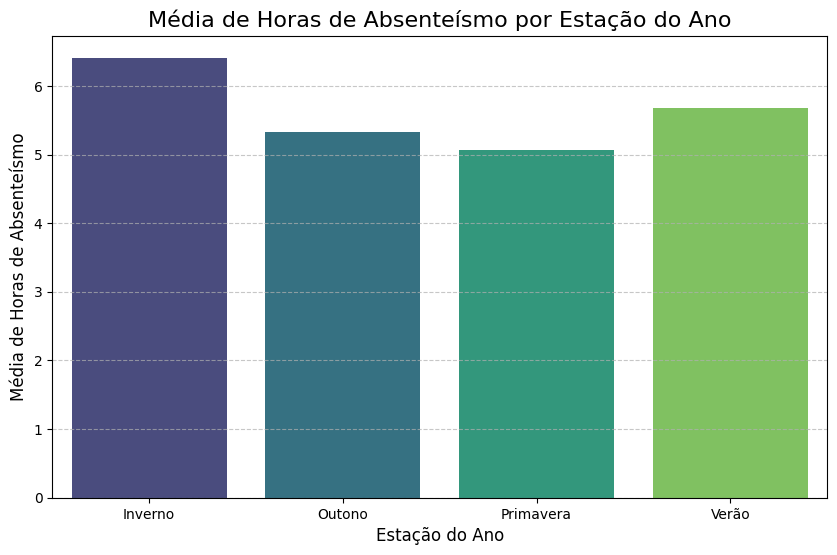

In [18]:
# Gráfico de Barras Agrupado: Horas de ausência por estação do ano (Seasons)
# Primeiro, é útil ter um mapeamento das estações para nomes mais legíveis, se disponível
# Se não, usaremos os números existentes ou inferiremos.
# No contexto, 'Seasons' é 1, 2, 3, 4. Vamos mapeá-los para nomes comuns.
season_names = {1: 'Verão', 2: 'Outono', 3: 'Inverno', 4: 'Primavera'}
df_tratado['Season_Name'] = df_tratado['Seasons'].map(season_names)

avg_absenteeism_season = df_tratado.groupby('Season_Name')['Absenteeism_time_in_hours'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Season_Name', y='Absenteeism_time_in_hours', data=avg_absenteeism_season, palette='viridis', hue='Season_Name', legend=False)
plt.title('Média de Horas de Absenteísmo por Estação do Ano', fontsize=16)
plt.xlabel('Estação do Ano', fontsize=12)
plt.ylabel('Média de Horas de Absenteísmo', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Opcional: remover a coluna temporária 'Season_Name' se não for mais necessária
df_tratado = df_tratado.drop(columns=['Season_Name'])

### Análise de Relações entre Variáveis

Vamos explorar as relações entre `Idade` ou `Tempo de Serviço` com `Horas de Absenteísmo`, e também comparar as horas de absenteísmo por `Nível de Escolaridade`.

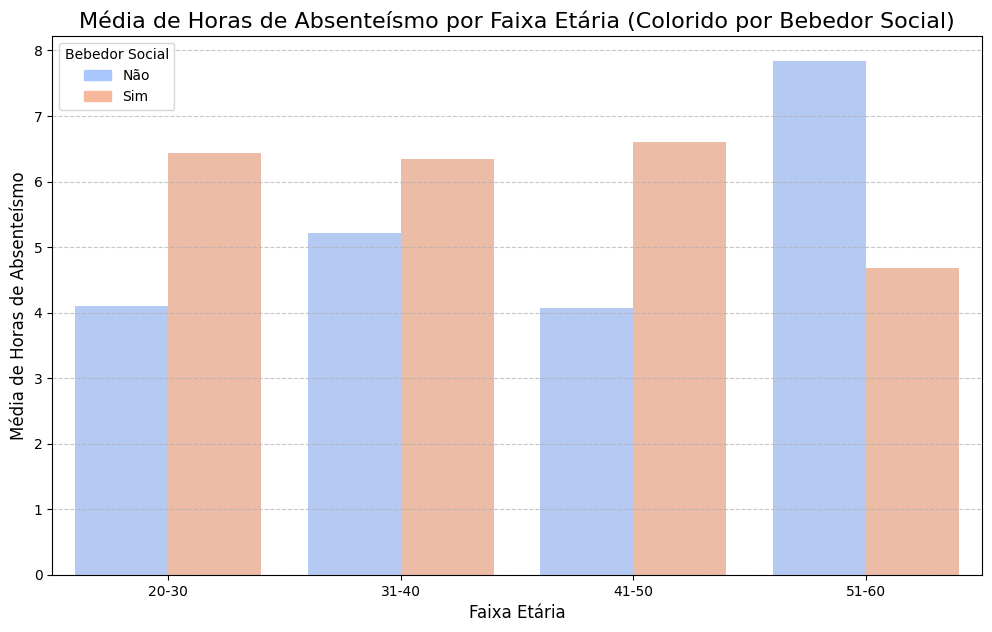

In [43]:
# Binned Bar Chart: Média de Horas de Absenteísmo por Faixa Etária, colorido por Social_drinker

# Criar faixas etárias (bins)
df_tratado['Age_Bin'] = pd.cut(df_tratado['Age'], bins=[20, 30, 40, 50, 60], labels=['20-30', '31-40', '41-50', '51-60'], right=False)

# Calcular a média de horas de absenteísmo por faixa etária e por bebedor social
avg_absenteeism_by_age_social = df_tratado.groupby(['Age_Bin', 'Social_drinker'], observed=False)['Absenteeism_time_in_hours'].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(x='Age_Bin', y='Absenteeism_time_in_hours', hue='Social_drinker', data=avg_absenteeism_by_age_social, palette='coolwarm')
plt.title('Média de Horas de Absenteísmo por Faixa Etária (Colorido por Bebedor Social)', fontsize=16)
plt.xlabel('Faixa Etária', fontsize=12)
plt.ylabel('Média de Horas de Absenteísmo', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Get the colors from the 'coolwarm' palette for Social_drinker (0 and 1)
colors = sns.color_palette('coolwarm', n_colors=2)

# Create custom legend handles with colored patches
import matplotlib.patches as mpatches
handles = [
    mpatches.Patch(color=colors[0], label='Não'), # Color for Social_drinker = 0
    mpatches.Patch(color=colors[1], label='Sim')  # Color for Social_drinker = 1
]
plt.legend(title='Bebedor Social', handles=handles)

plt.show()

# Opcional: remover a coluna temporária 'Age_Bin' se não for mais necessária
df_tratado = df_tratado.drop(columns=['Age_Bin'])

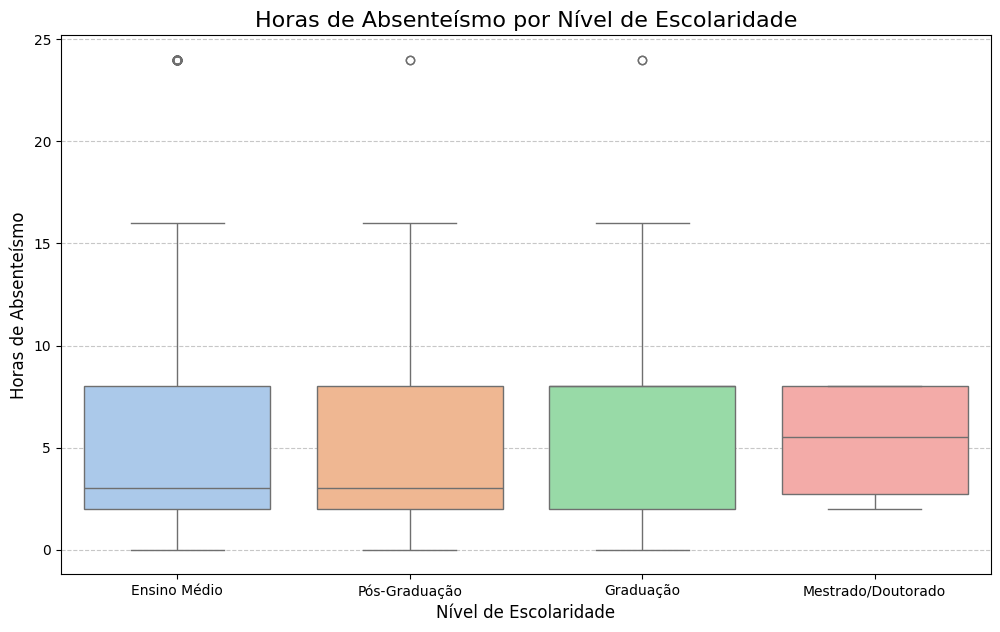

In [21]:
# Boxplot Comparativo: Horas de ausência por nível de escolaridade (Education)

# Mapear os níveis de escolaridade para nomes mais descritivos (se soubermos os valores)
# Assumindo que 1=Ensino Médio, 2=Graduação, 3=Pós-Graduação, 4=Mestrado/Doutorado, etc.
# Se não houver mapeamento específico, os números serão usados diretamente.
education_names = {1: 'Ensino Médio', 2: 'Graduação', 3: 'Pós-Graduação', 4: 'Mestrado/Doutorado'}
df_tratado['Education_Name'] = df_tratado['Education'].map(education_names).fillna(df_tratado['Education'])

plt.figure(figsize=(12, 7))
sns.boxplot(x='Education_Name', y='Absenteeism_time_in_hours', data=df_tratado, palette='pastel', hue='Education_Name', legend=False)
plt.title('Horas de Absenteísmo por Nível de Escolaridade', fontsize=16)
plt.xlabel('Nível de Escolaridade', fontsize=12)
plt.ylabel('Horas de Absenteísmo', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Opcional: remover a coluna temporária 'Education_Name' se não for mais necessária
df_tratado = df_tratado.drop(columns=['Education_Name'])


### Comparação: Média de faltas por nível de escolaridade ###


,Education_Name,Absenteeism_time_in_hours
0,Ensino Médio,5.668385
1,Graduação,6.043478
3,Pós-Graduação,4.932432
2,Mestrado/Doutorado,5.250000


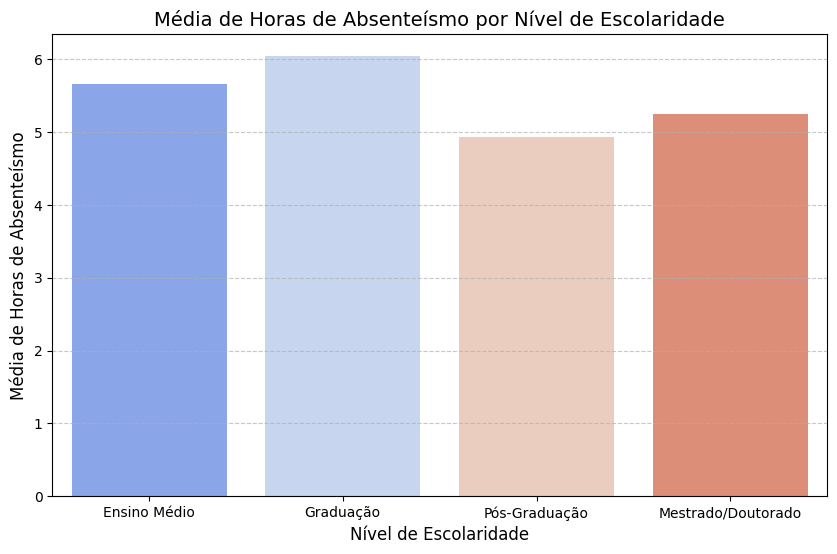

In [31]:
# Exemplo 2: Média de faltas por nível de escolaridade (Education).
print("\n### Comparação: Média de faltas por nível de escolaridade ###")

# Mapear os níveis de escolaridade para nomes mais descritivos
education_names = {1: 'Ensino Médio', 2: 'Graduação', 3: 'Pós-Graduação', 4: 'Mestrado/Doutorado'}
df_tratado['Education_Name'] = df_tratado['Education'].map(education_names)

avg_absenteeism_education = df_tratado.groupby('Education_Name')['Absenteeism_time_in_hours'].mean().reset_index()

# Ordenar para melhor visualização (Ensino Médio -> Graduação -> Pós-Graduação -> Mestrado/Doutorado)
order_education = ['Ensino Médio', 'Graduação', 'Pós-Graduação', 'Mestrado/Doutorado']
avg_absenteeism_education['Education_Name'] = pd.Categorical(avg_absenteeism_education['Education_Name'], categories=order_education, ordered=True)
avg_absenteeism_education = avg_absenteeism_education.sort_values('Education_Name')

display(avg_absenteeism_education[['Education_Name', 'Absenteeism_time_in_hours']])

# Gerar o gráfico de barras para escolaridade
plt.figure(figsize=(10, 6))
sns.barplot(x='Education_Name', y='Absenteeism_time_in_hours', data=avg_absenteeism_education, palette='coolwarm', hue='Education_Name', legend=False)
plt.title('Média de Horas de Absenteísmo por Nível de Escolaridade', fontsize=14)
plt.xlabel('Nível de Escolaridade', fontsize=12)
plt.ylabel('Média de Horas de Absenteísmo', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Remover a coluna temporária 'Education_Name' se não for mais necessária
df_tratado = df_tratado.drop(columns=['Education_Name'])

### Causas e Consequências
Principais causas de absenteísmos e o número de frequência delas

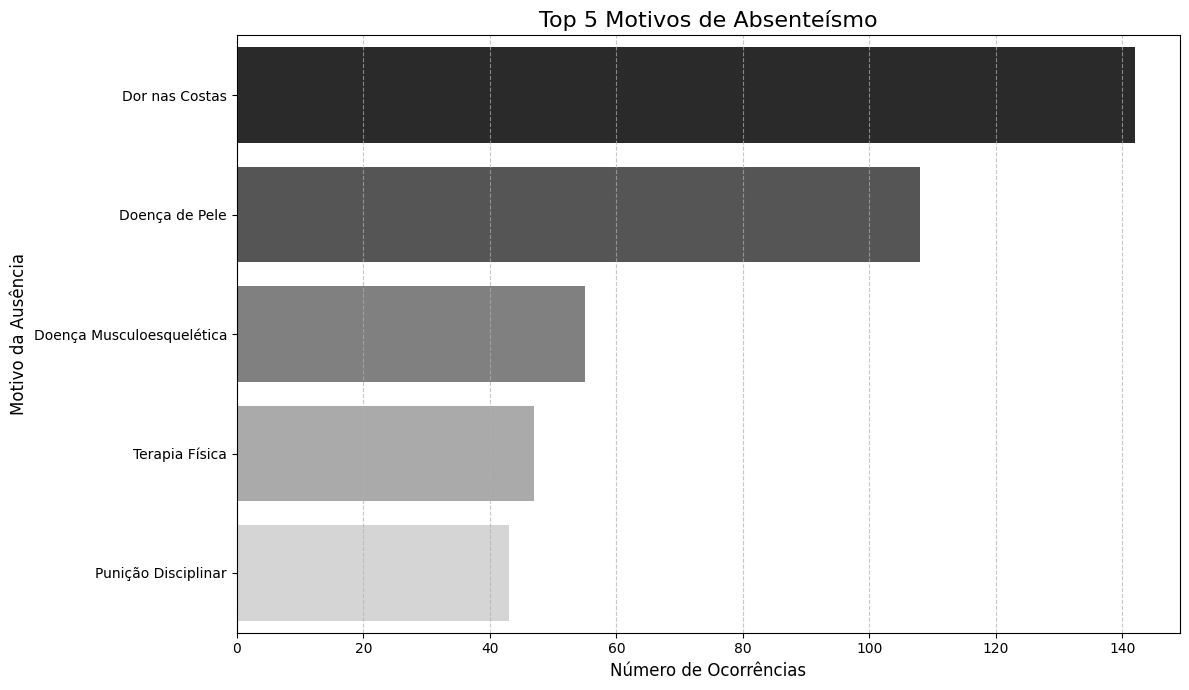

In [45]:
# Dicionário de mapeamento para as razões de ausência (exemplo, deve ser substituído pelo CID-10 real)
# Para obter a lista completa de códigos e suas descrições, o usuário deve fornecer um dicionário de dados
reason_mapping = {
    'Punição Disciplinar': 'Punição Disciplinar',
    1: 'Infecção Intestinal',
    2: 'Câncer',
    3: 'Migrânea',
    4: 'Doença do Olho',
    5: 'Doença do Sistema Circulatório',
    6: 'Doença do Sistema Respiratório',
    7: 'Doença da Boca e Dentes',
    8: 'Doença do Sistema Urinário',
    9: 'Doença do Sistema Endócrino',
    10: 'Transtornos Mentais',
    11: 'Problemas de Visão',
    12: 'Problemas de Ouvido',
    13: 'Doença Musculoesquelética',
    14: 'Gravidez',
    15: 'Acidentes de Carro',
    16: 'Lesão no Trabalho',
    17: 'Lesão por Esforço Repetitivo',
    18: 'Envenenamento',
    19: 'Lesão por Queda',
    20: 'Queimadura',
    21: 'Febre',
    22: 'Dores de Cabeça',
    23: 'Dor nas Costas',
    24: 'Estresse',
    25: 'Insônia',
    26: 'Dor de Dente',
    27: 'Terapia Física',
    28: 'Doença de Pele',

}

# Função para mapear os códigos para nomes descritivos, tratando strings que representam números
def map_reason_name(reason):
    if isinstance(reason, str) and reason.isdigit(): # Check if it's a string that looks like a number
        return reason_mapping.get(int(reason), reason) # Convert to int for lookup
    elif reason in reason_mapping:
        return reason_mapping[reason]
    else:
        return reason # Return original value if no mapping is found

# Mapear os códigos para nomes descritivos
df_tratado['Reason_Name'] = df_tratado['Reason_for_absence'].apply(map_reason_name)

# Calcular a frequência e pegar os Top 5
top_5_reasons = df_tratado['Reason_Name'].value_counts().head(5)

# Criar o gráfico de barras
plt.figure(figsize=(12, 7))
sns.barplot(x=top_5_reasons.values, y=top_5_reasons.index, palette='gray', hue=top_5_reasons.index, legend=False)
plt.title('Top 5 Motivos de Absenteísmo', fontsize=16)
plt.xlabel('Número de Ocorrências', fontsize=12)
plt.ylabel('Motivo da Ausência', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Opcional: remover a coluna temporária 'Reason_Name' se não for mais necessária
df_tratado = df_tratado.drop(columns=['Reason_Name'])

Causas com mais horas de Absenteísmo

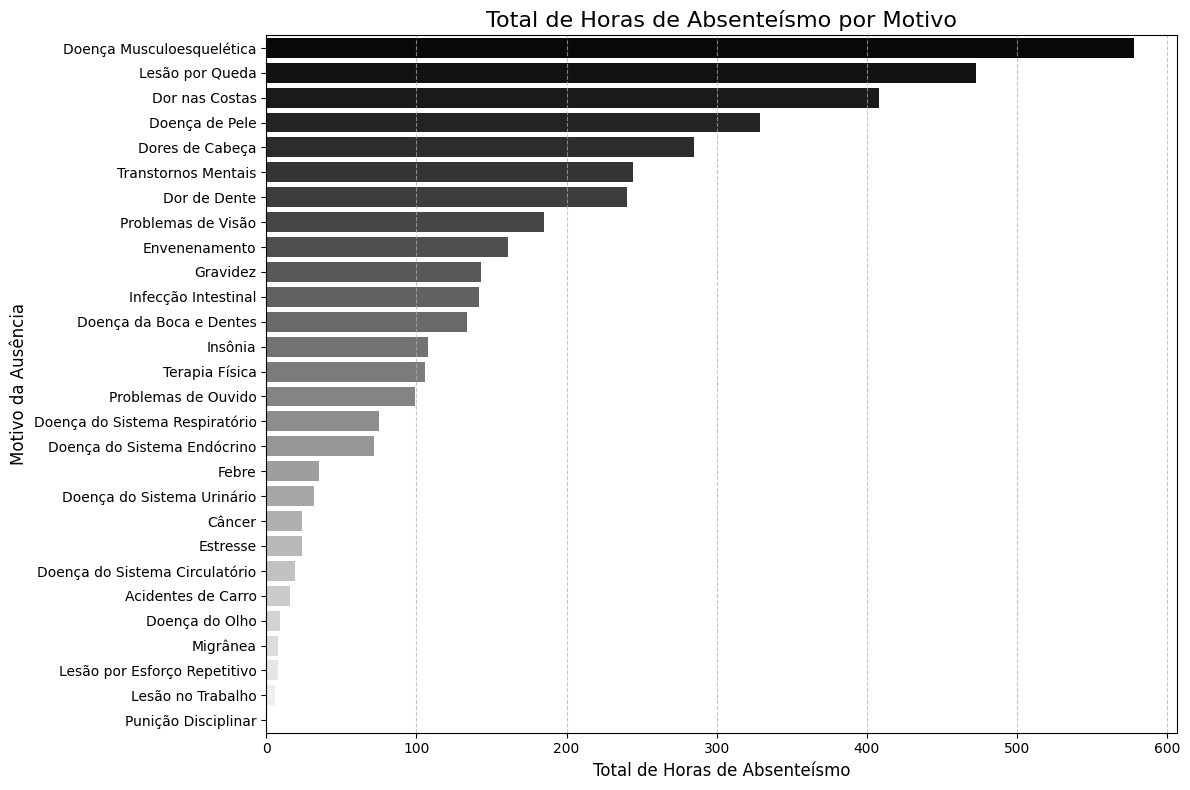

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reutilizando o mapeamento de razões que já foi definido
reason_mapping = {
    'Punição Disciplinar': 'Punição Disciplinar',
    1: 'Infecção Intestinal',
    2: 'Câncer',
    3: 'Migrânea',
    4: 'Doença do Olho',
    5: 'Doença do Sistema Circulatório',
    6: 'Doença do Sistema Respiratório',
    7: 'Doença da Boca e Dentes',
    8: 'Doença do Sistema Urinário',
    9: 'Doença do Sistema Endócrino',
    10: 'Transtornos Mentais',
    11: 'Problemas de Visão',
    12: 'Problemas de Ouvido',
    13: 'Doença Musculoesquelética',
    14: 'Gravidez',
    15: 'Acidentes de Carro',
    16: 'Lesão no Trabalho',
    17: 'Lesão por Esforço Repetitivo',
    18: 'Envenenamento',
    19: 'Lesão por Queda',
    20: 'Queimadura',
    21: 'Febre',
    22: 'Dores de Cabeça',
    23: 'Dor nas Costas',
    24: 'Estresse',
    25: 'Insônia',
    26: 'Dor de Dente',
    27: 'Terapia Física',
    28: 'Doença de Pele'
}

# Função para mapear os códigos para nomes descritivos, tratando strings que representam números
def map_reason_name(reason):
    if isinstance(reason, str) and reason.isdigit(): # Check if it's a string that looks like a number
        return reason_mapping.get(int(reason), reason) # Convert to int for lookup
    elif reason in reason_mapping:
        return reason_mapping[reason]
    else:
        return reason # Return original value if no mapping is found

# Mapear os códigos para nomes descritivos
df_tratado['Reason_Name_for_Plot'] = df_tratado['Reason_for_absence'].apply(map_reason_name)

# Agrupar por razão e somar as horas de absenteísmo
motivos_horas = df_tratado.groupby('Reason_Name_for_Plot')['Absenteeism_time_in_hours'].sum().reset_index()

# Ordenar do motivo com mais horas para o com menos horas
motivos_horas_sorted = motivos_horas.sort_values(by='Absenteeism_time_in_hours', ascending=False)

# Criar o gráfico de barras
plt.figure(figsize=(12, 8))
sns.barplot(x='Absenteeism_time_in_hours', y='Reason_Name_for_Plot', data=motivos_horas_sorted, palette='gray', hue='Reason_Name_for_Plot', legend=False)
plt.title('Total de Horas de Absenteísmo por Motivo', fontsize=16)
plt.xlabel('Total de Horas de Absenteísmo', fontsize=12)
plt.ylabel('Motivo da Ausência', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Opcional: remover a coluna temporária 'Reason_Name_for_Plot' se não for mais necessária
df_tratado = df_tratado.drop(columns=['Reason_Name_for_Plot'])

### Destaque 1: Fator Distância ###
Funcionários que moram a mais de 30km faltam 1.98% mais do que os que moram a 30km ou menos.

### Destaque 2: Fator Familiar ###
Média de horas de falta para colaboradores com filhos: 5.86 horas
Média de horas de falta para colaboradores sem filhos: 5.22 horas
Colaboradores com filhos faltam 12.20% mais do que colaboradores sem filhos.

### Destaque 3: Fator Disciplinar ###
6.09% das 'faltas' registradas são, na verdade, questões de conduta, não de saúde.
